In [1]:
import pandas as pd
import re
import nltk

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

print("Library berhasil di-import!")

Library berhasil di-import!


In [2]:
df = pd.read_csv(
    "dataset_detik.csv",
    sep=";",
    encoding="utf-8-sig"
)

print("Dataset berhasil dibaca!")
print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

display(df.head())

Dataset berhasil dibaca!
Jumlah data: 200
Jumlah kolom: 3


,id,isi_berita,label
0,1,Ciamis - Sebanyak 549 siswa dari 40 SD mengiku...,sport
1,2,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",sport
2,3,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",sport
3,4,Di tengah viral insiden cepirit pada ajang Hyr...,sport
4,5,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,sport


In [3]:
print("Contoh berita sebelum preprocessing:\n")
print(df["isi_berita"].iloc[0])

print("\nPanjang teks berita pertama:")
print(len(df["isi_berita"].iloc[0]))

print("\nDistribusi label:")
print(df["label"].value_counts())

Contoh berita sebelum preprocessing:

Ciamis - Sebanyak 549 siswa dari 40 SD mengikuti lomba olahraga tradisional di Ciamis, Jawa Barat, dengan penuh semangat.
Sejumlah peserta beradu cepat dalam lomba olahraga tradisional (Oltrad) egrang di Lapang Cigorowong, Kabupaten Ciamis, Jawa Barat, Rabu (16/9/2026). Para siswa beradu kemampuan dalam lima cabang olahraga tradisional, yakni hadang, terompah panjang, dagongan, sumpitan, dan egrang. Setiap pertandingan menghadirkan keseruan sekaligus mengajak peserta mengenal permainan tradisional. ANTARA FOTO/Adeng Bustomi
Salah satu perlombaan yang menarik perhatian adalah dagongan. Dalam pertandingan tersebut, peserta saling mendorong batang bambu dengan mengandalkan kekuatan, keseimbangan, dan kerja sama tim. ANTARA FOTO/Adeng Bustomi
Kejuaraan olahraga tradisional tersebut menjadi sarana edukasi bagi siswa sekaligus bagian dari upaya melestarikan budaya. Melalui kegiatan ini, olahraga tradisional dikenalkan kepada generasi muda agar tetap dima

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
stop_words = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("Jumlah stopword:", len(stop_words))
print("Stemmer Bahasa Indonesia berhasil dibuat!")

Jumlah stopword: 757
Stemmer Bahasa Indonesia berhasil dibuat!


In [6]:
# membuat Fungsi Prepocessing
def preprocessing_teks(teks):
    # 1. Case folding
    teks = teks.lower()

    # 2. Menghapus URL
    teks = re.sub(r"http\S+|www\S+", "", teks)

    # 3. Menghapus angka
    teks = re.sub(r"\d+", "", teks)

    # 4. Menghapus tanda baca dan karakter khusus
    teks = re.sub(r"[^a-zA-Z\s]", " ", teks)

    # 5. Menghapus spasi berlebih
    teks = re.sub(r"\s+", " ", teks).strip()

    # 6. Tokenisasi sederhana
    tokens = teks.split()

    # 7. Stopword removal
    tokens = [kata for kata in tokens if kata not in stop_words]

    # 8. Stemming Bahasa Indonesia
    tokens = [stemmer.stem(kata) for kata in tokens]

    # Menggabungkan kembali menjadi teks
    return " ".join(tokens)


print("Fungsi preprocessing berhasil dibuat!")

Fungsi preprocessing berhasil dibuat!


In [7]:
df["teks_preprocessed"] = df["isi_berita"].apply(preprocessing_teks)

print("Preprocessing selesai!")
display(df[["id", "isi_berita", "teks_preprocessed", "label"]].head())

Preprocessing selesai!


,id,isi_berita,teks_preprocessed,label
0,1,Ciamis - Sebanyak 549 siswa dari 40 SD mengiku...,ciamis siswa sd ikut lomba olahraga tradisiona...,sport
1,2,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",seri motogp marc marquez sukses sapu bersih po...,sport
2,3,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",alwi farhan moh zaki ubaidillah muhamad yusuf ...,sport
3,4,Di tengah viral insiden cepirit pada ajang Hyr...,viral insiden cepirit ajang hyrox atlet malays...,sport
4,5,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,dejan fedinansyah felisha alberta nathaniel pa...,sport


In [8]:
# Ektrak Kata Unik
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TF-IDF
vectorizer = TfidfVectorizer()

# Mengubah teks hasil preprocessing menjadi matriks TF-IDF
tfidf_matrix = vectorizer.fit_transform(df["teks_preprocessed"])

print("TF-IDF berhasil dibuat!")
print("Jumlah dokumen :", tfidf_matrix.shape[0])
print("Jumlah fitur/kata unik :", tfidf_matrix.shape[1])

TF-IDF berhasil dibuat!
Jumlah dokumen : 200
Jumlah fitur/kata unik : 5068


In [9]:
# Mengubah matriks TF-IDF menjadi array dense (dipakai juga untuk PCA)
tfidf_dense = tfidf_matrix.toarray()

# Nama kolom kata. Kata "id" / "label" diberi awalan supaya tidak bentrok
# dengan kolom "id" dan "label" milik dataset.
nama_kata = [
    f"kata_{k}" if k in ("id", "label") else k
    for k in vectorizer.get_feature_names_out()
]

# Mengubah matriks TF-IDF menjadi DataFrame
tfidf_df = pd.DataFrame(tfidf_dense, columns=nama_kata)

# Menambahkan ID dan label
tfidf_df = pd.concat([
    df[["id"]].reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
    df[["label"]].reset_index(drop=True)
], axis=1)

# Pastikan tidak ada nama kolom ganda
assert tfidf_df.columns.is_unique, "Ada nama kolom ganda di tfidf_df!"

# Menampilkan hasil TF-IDF
display(tfidf_df)

,id,aaa,aau,ab,abad,abadi,abai,abal,abdullah,abdurrahkman,...,zein,zen,zg,zhejiang,zheng,zhestkova,zhulkifli,zona,zverev,label
0,1,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
1,2,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
2,3,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
3,4,0.000000,0.0,0.0,0.0,0.000000,0.053127,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
4,5,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,finance
196,197,0.000000,0.0,0.0,0.0,0.074463,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,finance
197,198,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,finance
198,199,0.047257,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,finance


In [10]:
# Fungsi untuk menyimpan DataFrame ke CSV lalu mengunduhnya
import os
from IPython.display import FileLink, display

def simpan_dan_unduh(dataframe, nama_file):
    """Simpan DataFrame ke CSV, lalu unduh.
    - Google Colab : file langsung terunduh ke komputer.
    - Jupyter lokal: file tersimpan di folder notebook + muncul link file.
    """
    dataframe.to_csv(nama_file, index=False, encoding="utf-8-sig")
    ukuran_kb = os.path.getsize(nama_file) / 1024
    print(f"Tersimpan: {nama_file} "
          f"({dataframe.shape[0]} baris x {dataframe.shape[1]} kolom, {ukuran_kb:,.0f} KB)")

    try:
        from google.colab import files      # hanya tersedia di Google Colab
        files.download(nama_file)
    except ImportError:
        display(FileLink(nama_file))        # Jupyter lokal

In [11]:
# Menyimpan & mengunduh data SEBELUM PCA (matriks TF-IDF)
simpan_dan_unduh(tfidf_df, "hasil_tfidf.csv")

Tersimpan: hasil_tfidf.csv (200 baris x 5070 kolom, 4,342 KB)


D:\PPW\hasil_tfidf.csv

In [12]:
fitur_kata = vectorizer.get_feature_names_out()

print("Jumlah seluruh kata unik:", len(fitur_kata))
print(fitur_kata[:200])

Jumlah seluruh kata unik: 5068
['aaa' 'aau' 'ab' 'abad' 'abadi' 'abai' 'abal' 'abdullah' 'abdurrahkman'
 'abet' 'abha' 'abraham' 'abrahham' 'absen' 'absorber' 'abu' 'academy'
 'acara' 'accelerating' 'acceptance' 'access' 'accessories' 'accident'
 'accreditation' 'acd' 'ace' 'aceh' 'achadie' 'achilles' 'achmad' 'acosta'
 'acu' 'ada' 'adam' 'adaptasi' 'adaptif' 'adb' 'adcp' 'ade' 'adelaide'
 'adelguer' 'adella' 'adeng' 'adhang' 'adhi' 'adhipramana' 'adhitama'
 'adi' 'adibha' 'adik' 'adil' 'adinata' 'aditya' 'administrasi'
 'administratif' 'administrator' 'adp' 'adr' 'adrenalin' 'adrian'
 'adrianto' 'adshila' 'adu' 'aduh' 'adventure' 'aerox' 'afc' 'aff'
 'afiliasi' 'afirmasi' 'agam' 'agen' 'agenda' 'agius' 'agraria'
 'agreement' 'agresif' 'agribisnis' 'agung' 'agus' 'agusman' 'agustus'
 'ahhn' 'ahi' 'ahli' 'ahmad' 'ahren' 'ahy' 'ahza' 'ai' 'aichi' 'ailsie'
 'ain' 'air' 'aira' 'airport' 'aja' 'ajaib' 'ajak' 'ajang' 'ajar' 'ajeng'
 'aji' 'aju' 'akademi' 'akademik' 'akademisi' 'akal' 'akar' 

In [13]:
from sklearn.decomposition import PCA

# PCA dengan tepat 138 komponen
# 200 dokumen -> 200 baris, 138 komponen -> 138 kolom PCA
pca = PCA(n_components=138)
tfidf_pca = pca.fit_transform(tfidf_dense)

print("PCA berhasil dilakukan!")
print("Ukuran data sebelum PCA :", tfidf_dense.shape)
print("Ukuran data setelah PCA :", tfidf_pca.shape)
print("\nJumlah komponen PCA :", pca.n_components_)
print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())


PCA berhasil dilakukan!
Ukuran data sebelum PCA : (200, 5068)
Ukuran data setelah PCA : (200, 138)

Jumlah komponen PCA : 138

Total Explained Variance:
0.9006656356057265


In [14]:
# Membuat DataFrame hasil PCA
pca_columns = [f"PC{i+1}" for i in range(tfidf_pca.shape[1])]
df_pca = pd.DataFrame(tfidf_pca, columns=pca_columns)

# Menambahkan id di awal dan label di akhir
df_pca.insert(0, "id", df["id"].values)
df_pca["label"] = df["label"].values

print("Data hasil PCA:")
print("Ukuran data PCA :", df_pca.shape)
display(df_pca.head())


Data hasil PCA:
Ukuran data PCA : (200, 140)


,id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,label
0,1,-0.051591,-0.084691,-0.007764,-0.034387,-0.033033,-0.074662,0.079820,-0.074714,0.011044,...,-0.003693,-0.018177,0.013615,0.005408,-0.005205,0.012910,-0.018513,-0.004313,-0.010166,sport
1,2,0.476904,0.043411,0.005327,0.017750,-0.247570,0.137023,-0.096207,-0.046649,-0.068151,...,0.101996,0.034978,0.085014,0.063849,-0.089466,-0.087056,-0.032035,-0.011615,-0.071770,sport
2,3,-0.090811,-0.309354,-0.131577,0.285930,0.111117,0.079826,-0.117351,-0.028175,-0.077481,...,-0.079538,0.032920,0.021651,-0.018413,-0.052655,0.000821,0.049882,-0.058254,-0.062612,sport
3,4,-0.035140,-0.060473,-0.015913,-0.041771,-0.019447,-0.021548,0.018285,-0.021832,0.069742,...,-0.041165,0.009338,-0.055202,-0.027958,-0.000241,0.066170,0.082378,-0.001000,0.073663,sport
4,5,-0.096657,-0.327272,-0.142540,0.328643,0.143831,0.153140,-0.159294,0.077913,-0.043123,...,0.006965,-0.002127,-0.001126,0.043198,-0.052112,-0.007570,-0.002406,-0.039404,0.019943,sport


In [15]:
# Menyimpan & mengunduh data SETELAH PCA
simpan_dan_unduh(df_pca, "hasil_pca.csv")


Tersimpan: hasil_pca.csv (200 baris x 140 kolom, 567 KB)


D:\PPW\hasil_pca.csv

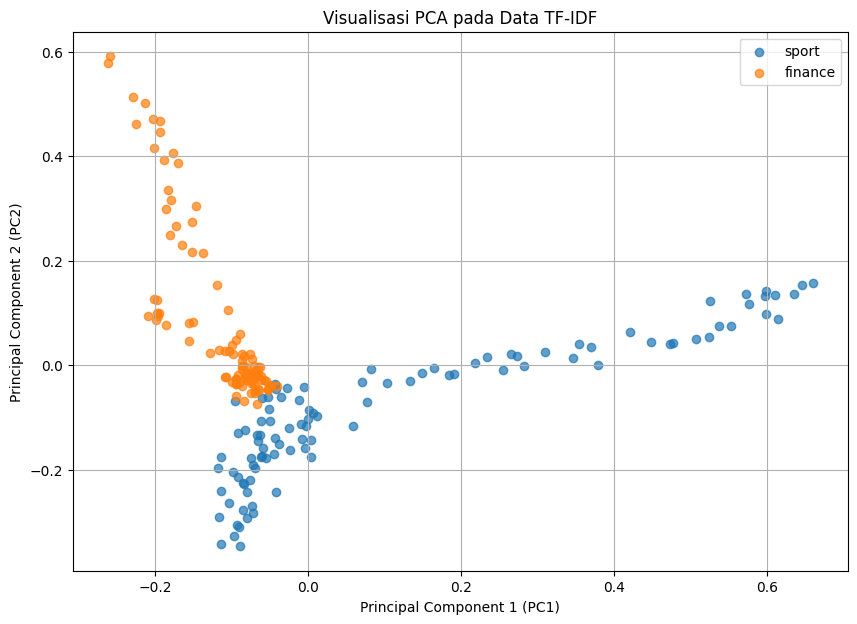

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for label in df_pca["label"].unique():
    data = df_pca[df_pca["label"] == label]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=label,
        alpha=0.7
    )

plt.title("Visualisasi PCA pada Data TF-IDF")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.grid(True)
plt.show()